# Data Cleaning and Preparation 

## 1. Import any sample dataset in Pandas and perform the following: 

## 1.1 Handle missing data by filtering, dropping, filling missing values. 

## import data

In [2]:
import pandas as pd

books = pd.read_csv(
    r"C:\Users\ramya\Downloads\Collaborative-Filtering-Book-Recommendation-System-master\Collaborative-Filtering-Book-Recommendation-System-master\BX-Books.csv",
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip",
    engine="python"
)

print("Loaded Successfully!")
print(books.shape)
print(books.head())

Loaded Successfully!
(270491, 8)
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/01951534

### Handling Missing Data


#### Detect Missing Values

In [3]:
# Check for missing values in each column
print(books.isnull().sum())

# 1. isnull() returns True for NaN
# 2. sum() counts missing values per column
# 3. Useful for data quality check

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64


#### Filter Rows with Missing Values

In [4]:
# Select rows where Publisher is missing
missing_publishers = books[books["Publisher"].isnull()]
print("Rows with missing Publisher:\n", missing_publishers.head())

# 1. Boolean mask filters rows
# 2. Keeps only rows with NaN in Publisher

Rows with missing Publisher:
               ISBN       Book-Title      Book-Author  Year-Of-Publication  \
128497  193169656X      Tyrant Moon  Elaine Corvidae                 2002   
128644  1931696993  Finders Keepers  Linnea Sinclair                 2001   

       Publisher                                        Image-URL-S  \
128497       NaN  http://images.amazon.com/images/P/193169656X.0...   
128644       NaN  http://images.amazon.com/images/P/1931696993.0...   

                                              Image-URL-M  \
128497  http://images.amazon.com/images/P/193169656X.0...   
128644  http://images.amazon.com/images/P/1931696993.0...   

                                              Image-URL-L  
128497  http://images.amazon.com/images/P/193169656X.0...  
128644  http://images.amazon.com/images/P/1931696993.0...  


#### Drop Rows with Missing Values

In [5]:
# Drop rows with any missing values
books_dropped = books.dropna()
print("After dropping rows with NaN:\n", books_dropped.head())

# 1. dropna() removes rows containing NaN
# 2. Returns new DataFrame
# 3. Original unchanged unless inplace=True

After dropping rows with NaN:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448

#### Drop Columns with Missing Values

In [6]:
# Drop columns with any missing values
books_dropped_cols = books.dropna(axis=1)
print("After dropping columns with NaN:\n", books_dropped_cols.head())

# 1. axis=1 applies to columns
# 2. Removes entire column if it has NaN

After dropping columns with NaN:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

   Year-Of-Publication                                        Image-URL-S  \
0                 2002  http://images.amazon.com/images/P/0195153448.0...   
1                 2001  http://images.amazon.com/images/P/0002005018.0...   
2                 1991  http://images.amazon.com/images/P/0060973129.0...   
3                 1999  http://images.amazon.com/images/P/0374157065.0...   
4                 1999  http://images.amazon.com/images/P/0393045218.0...   

                                         Image-URL-M  \
0  http://images.amazon.com/images/P/0

#### Fill Missing Values with Constant

In [7]:
# Fill missing Publisher with "Unknown"
books_filled = books.fillna({"Publisher":"Unknown"})
print("After filling Publisher:\n", books_filled.head())

# 1. fillna replaces NaN with given value
# 2. Dictionary allows column-specific fills

After filling Publisher:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...

#### Fill Missing Values with Forward Fill

In [8]:
# Forward fill (propagate previous value)
books_ffill = books.fillna(method="ffill")
print("After forward fill:\n", books_ffill.head())

# 1. ffill copies previous non-null value
# 2. Useful for time series data

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

#### Fill Missing Values with Mean/Median

In [9]:
# Fill missing Year with mean
books["Year-Of-Publication"] = books["Year-Of-Publication"].fillna(books["Year-Of-Publication"].mean())
print("After filling Year with mean:\n", books.head())

# 1. Numeric columns can use mean/median
# 2. Useful for statistical imputation

After filling Year with mean:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448

####  Replace Specific Values with NaN


In [10]:
import numpy as np

# Replace invalid year 0 with NaN
books["Year-Of-Publication"] = books["Year-Of-Publication"].replace(0, np.nan)
print("After replacing 0 with NaN:\n", books.head())

# 1. replace() converts invalid values to NaN
# 2. Useful for cleaning data

After replacing 0 with NaN:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford               2002.0     Oxford University Press   
1  Richard Bruce Wright               2001.0       HarperFlamingo Canada   
2          Carlo D'Este               1991.0             HarperPerennial   
3      Gina Bari Kolata               1999.0        Farrar Straus Giroux   
4       E. J. W. Barber               1999.0  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0

#### Interpolate Missing Values

In [11]:
# Interpolate numeric values
books["Year-Of-Publication"] = books["Year-Of-Publication"].interpolate()
print("After interpolation:\n", books.head())

# 1. interpolate estimates missing values
# 2. Linear interpolation by default
# 3. Useful for continuous data

After interpolation:
          ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford               2002.0     Oxford University Press   
1  Richard Bruce Wright               2001.0       HarperFlamingo Canada   
2          Carlo D'Este               1991.0             HarperPerennial   
3      Gina Bari Kolata               1999.0        Farrar Straus Giroux   
4       E. J. W. Barber               1999.0  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   


## 1.2 Remove Duplicates, Replace Values, Rename single / multiple columns 

## 1.2.1 Remove Duplicates

### Drop duplicate rows

In [3]:
df1 = books.drop_duplicates()
print(df1.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Drop duplicates based on ISBN

In [4]:
df2 = books.drop_duplicates(subset=["ISBN"])
print(df2.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Drop duplicates based on Title

In [5]:
df3 = books.drop_duplicates(subset=["Book-Title"])
print(df3.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Keep last occurrence

In [6]:
df4 = books.drop_duplicates(keep="last")
print(df4.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Drop duplicates inplace

In [7]:
books_copy = books.copy()
books_copy.drop_duplicates(inplace=True)
print(books_copy.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Drop duplicates across multiple columns

In [8]:
df6 = books.drop_duplicates(subset=["ISBN","Book-Title"])
print(df6.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

### Count duplicates

In [9]:
dup_count = books.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


### Mark duplicates with boolean mask

In [10]:
dup_mask = books.duplicated()
print(dup_mask.head())

0    False
1    False
2    False
3    False
4    False
dtype: bool


###  Keep only duplicates

In [11]:
df9 = books[books.duplicated(keep=False)]
print(df9.head())

Empty DataFrame
Columns: [ISBN, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S, Image-URL-M, Image-URL-L]
Index: []


### Drop duplicates ignoring index

In [12]:
df10 = books.reset_index().drop_duplicates()
print(df10.head())

   index        ISBN                                         Book-Title  \
0      0  0195153448                                Classical Mythology   
1      1  0002005018                                       Clara Callan   
2      2  0060973129                               Decision in Normandy   
3      3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4      4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P

### Drop duplicates in a Series

In [13]:
s = pd.Series([1,1,2,3,3])
print(s.drop_duplicates())

0    1
2    2
3    3
dtype: int64


### Drop duplicates with NaN

In [15]:
import numpy as np
df_nan = pd.DataFrame({"A":[1,1,np.nan,np.nan]})
print(df_nan.drop_duplicates())

     A
0  1.0
2  NaN


### Drop duplicates and count unique

In [16]:
unique_count = books["ISBN"].nunique()
print("Unique ISBN count:", unique_count)

Unique ISBN count: 270491


### Drop duplicates and sort

In [17]:
df15 = books.drop_duplicates().sort_values("ISBN")
print(df15.head())

              ISBN                                         Book-Title  \
253433  0000913154  The Way Things Work: An Illustrated Encycloped...   
215120  0001010565                                    Mog's Christmas   
42464   0001046438                                               Liar   
112214  0001046713                       Twopence to Cross the Mersey   
145724  0001046934                      The Prime of Miss Jean Brodie   

                          Book-Author  Year-Of-Publication  \
253433  C. van Amerongen (translator)                 1967   
215120                    Judith Kerr                 1992   
42464                     Stephen Fry                    0   
112214                Helen Forrester                 1992   
145724                   Muriel Spark                 1999   

                          Publisher  \
253433         Simon &amp; Schuster   
215120                      Collins   
42464              Harpercollins Uk   
112214     HarperCollins Publish

## 1.2.2 Replace Values

### Replace 0 with NaN


In [22]:
import numpy as np

books["Year-Of-Publication"] = books["Year-Of-Publication"].replace(0, np.nan)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2000.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


###  Replace multiple values

In [23]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].replace([0,1999], np.nan)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2000.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace using dictionary


In [24]:
books["Publisher"] = books["Publisher"].replace({
    "Oxford University Press":"OUP",
    "Cambridge University Press":"CUP"
})
print(books[["Book-Title","Publisher"]].head(10))

                                          Book-Title  \
0                                Classical Mythology   
1                                       Clara Callan   
2                               Decision in Normandy   
3  Flu: The Story of the Great Influenza Pandemic...   
4                             The Mummies of Urumchi   
5                             The Kitchen God's Wife   
6  What If?: The World's Foremost Military Histor...   
7                                    PLEADING GUILTY   
8  Under the Black Flag: The Romance and the Real...   
9            Where You'll Find Me: And Other Stories   

                    Publisher  
0                         OUP  
1       HarperFlamingo Canada  
2             HarperPerennial  
3        Farrar Straus Giroux  
4  W. W. Norton &amp; Company  
5            Putnam Pub Group  
6    Berkley Publishing Group  
7                  Audioworks  
8                Random House  
9                    Scribner  


### Replace using regex

In [25]:
books["Publisher"] = books["Publisher"].replace(r"^O.*","OUP", regex=True)
print(books[["Book-Title","Publisher"]].head(10))

                                          Book-Title  \
0                                Classical Mythology   
1                                       Clara Callan   
2                               Decision in Normandy   
3  Flu: The Story of the Great Influenza Pandemic...   
4                             The Mummies of Urumchi   
5                             The Kitchen God's Wife   
6  What If?: The World's Foremost Military Histor...   
7                                    PLEADING GUILTY   
8  Under the Black Flag: The Romance and the Real...   
9            Where You'll Find Me: And Other Stories   

                    Publisher  
0                         OUP  
1       HarperFlamingo Canada  
2             HarperPerennial  
3        Farrar Straus Giroux  
4  W. W. Norton &amp; Company  
5            Putnam Pub Group  
6    Berkley Publishing Group  
7                  Audioworks  
8                Random House  
9                    Scribner  


###  Replace inplace

In [26]:
books_copy = books.copy()
books_copy.replace("Random House","RND", inplace=True)
print(books_copy[["Book-Title","Publisher"]].head(10))

                                          Book-Title  \
0                                Classical Mythology   
1                                       Clara Callan   
2                               Decision in Normandy   
3  Flu: The Story of the Great Influenza Pandemic...   
4                             The Mummies of Urumchi   
5                             The Kitchen God's Wife   
6  What If?: The World's Foremost Military Histor...   
7                                    PLEADING GUILTY   
8  Under the Black Flag: The Romance and the Real...   
9            Where You'll Find Me: And Other Stories   

                    Publisher  
0                         OUP  
1       HarperFlamingo Canada  
2             HarperPerennial  
3        Farrar Straus Giroux  
4  W. W. Norton &amp; Company  
5            Putnam Pub Group  
6    Berkley Publishing Group  
7                  Audioworks  
8                         RND  
9                    Scribner  


### Replace list of values with one

In [29]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].replace([2000,2010],2020)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace using Series map


In [30]:
books["Publisher"] = books["Publisher"].map({
    "OUP":"Oxford",
    "CUP":"Cambridge",
    "Random House":"RND"
})
print(books[["Book-Title","Publisher"]].head(10))






                                          Book-Title Publisher
0                                Classical Mythology    Oxford
1                                       Clara Callan       NaN
2                               Decision in Normandy       NaN
3  Flu: The Story of the Great Influenza Pandemic...       NaN
4                             The Mummies of Urumchi       NaN
5                             The Kitchen God's Wife       NaN
6  What If?: The World's Foremost Military Histor...       NaN
7                                    PLEADING GUILTY       NaN
8  Under the Black Flag: The Romance and the Real...       RND
9            Where You'll Find Me: And Other Stories       NaN


### Replace using apply

In [31]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].apply(lambda x: np.nan if x==0 else x)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace using where

In [32]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].where(books["Year-Of-Publication"]!=0, np.nan)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace using mask

In [33]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].mask(books["Year-Of-Publication"]==0, np.nan)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...                  NaN
4                             The Mummies of Urumchi                  NaN
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace with fillna after replace



In [34]:
books["Year-Of-Publication"] = books["Year-Of-Publication"].replace(0,np.nan).fillna(2001)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...               2001.0
4                             The Mummies of Urumchi               2001.0
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Replace with condition

In [35]:
books.loc[books["Year-Of-Publication"]==2005,"Year-Of-Publication"]=2015
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...               2001.0
4                             The Mummies of Urumchi               2001.0
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


###  Replace using dict across multiple columns

In [36]:
books = books.replace({
    "Year-Of-Publication":{0:np.nan},
    "Publisher":{"Random House":"RND"}
})
print(books.head(10))

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Ko

## 1.2.3 Rename single / multiple columns 

### Rename a single column

In [38]:
books1 = books.rename(columns={"Book-Title":"Title"})
print(books1.head())

         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename multiple columns

In [39]:
books2 = books.rename(columns={
    "Book-Title":"Title",
    "Book-Author":"Author"
})
print(books2.head())

         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename inplace

In [42]:
books_copy = books.copy()
books_copy.rename(columns={"Book-Title":"Title"}, inplace=True)
print(books_copy.head())

         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with function (lowercase)

In [43]:
books4 = books.rename(columns=str.lower)
print(books4.head())

         isbn                                         book-title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            book-author  year-of-publication publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         image-url-s  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with function (uppercase)

In [44]:
books5 = books.rename(columns=str.upper)
print(books5.head())

         ISBN                                         BOOK-TITLE  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            BOOK-AUTHOR  YEAR-OF-PUBLICATION PUBLISHER  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         IMAGE-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with lambda (replace hyphen with underscore)

In [45]:
books6 = books.rename(columns=lambda x: x.replace("-","_"))
print(books6.head())

         ISBN                                         Book_Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book_Author  Year_Of_Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image_URL_S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with list assignment

In [49]:
books7 = books.copy()
books7 = books7.rename(columns={
    "Book-Title":"Title",
    "Book-Author":"Author",
    "Year-Of-Publication":"Year",
    "Publisher":"Publisher",
    "ISBN":"Code"
})
print(books7.head())

         Code                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Author    Year Publisher  \
0    Mark P. O. Morford  2002.0    Oxford   
1  Richard Bruce Wright  2001.0       NaN   
2          Carlo D'Este  1991.0       NaN   
3      Gina Bari Kolata  2001.0       NaN   
4       E. J. W. Barber  2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.amazon.com/images/P/0374157065.0...   
4  http://images.amazon.com/images/P/039

### Add prefix to all columns


In [50]:
books8 = books.add_prefix("BX_")
print(books8.head())

      BX_ISBN                                      BX_Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

         BX_Book-Author  BX_Year-Of-Publication BX_Publisher  \
0    Mark P. O. Morford                  2002.0       Oxford   
1  Richard Bruce Wright                  2001.0          NaN   
2          Carlo D'Este                  1991.0          NaN   
3      Gina Bari Kolata                  2001.0          NaN   
4       E. J. W. Barber                  2001.0          NaN   

                                      BX_Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0

###  Add suffix to all columns





In [51]:
books9 = books.add_suffix("_col")
print(books9.head())



     ISBN_col                                     Book-Title_col  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

        Book-Author_col  Year-Of-Publication_col Publisher_col  \
0    Mark P. O. Morford                   2002.0        Oxford   
1  Richard Bruce Wright                   2001.0           NaN   
2          Carlo D'Este                   1991.0           NaN   
3      Gina Bari Kolata                   2001.0           NaN   
4       E. J. W. Barber                   2001.0           NaN   

                                     Image-URL-S_col  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.co

### Rename selected column only

In [52]:
books10 = books.rename(columns={"Year-Of-Publication":"Year"})
print(books10.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author    Year Publisher  \
0    Mark P. O. Morford  2002.0    Oxford   
1  Richard Bruce Wright  2001.0       NaN   
2          Carlo D'Este  1991.0       NaN   
3      Gina Bari Kolata  2001.0       NaN   
4       E. J. W. Barber  2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.amazon.com/images/P/0374157065.0...   
4  http://images.amazon.com/images/P/039

### Rename using dictionary partial

In [53]:
books11 = books.rename(columns={"Book-Author":"Writer"})
print(books11.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Writer  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with str.title

In [54]:
books12 = books.rename(columns=str.title)
print(books12.head())

         Isbn                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-Url-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Rename with str.strip (remove spaces)

In [55]:
books13 = books.rename(columns=lambda x: x.strip())
print(books13.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0       NaN   
2          Carlo D'Este               1991.0       NaN   
3      Gina Bari Kolata               2001.0       NaN   
4       E. J. W. Barber               2001.0       NaN   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Reindex columns (reorder/rename)

In [57]:
books15 = books.reindex(columns=["Book-Title","Book-Author","Year-Of-Publication","Publisher"])
print(books15.head())

                                          Book-Title           Book-Author  \
0                                Classical Mythology    Mark P. O. Morford   
1                                       Clara Callan  Richard Bruce Wright   
2                               Decision in Normandy          Carlo D'Este   
3  Flu: The Story of the Great Influenza Pandemic...      Gina Bari Kolata   
4                             The Mummies of Urumchi       E. J. W. Barber   

   Year-Of-Publication Publisher  
0               2002.0    Oxford  
1               2001.0       NaN  
2               1991.0       NaN  
3               2001.0       NaN  
4               2001.0       NaN  


## 1.3 Transform data using a Function or Mapping to handle missing data 

### Use apply() with a custom function


In [58]:
# Replace NaN in Publisher with "Unknown"
books["Publisher"] = books["Publisher"].apply(lambda x: "Unknown" if pd.isna(x) else x)
print(books[["Book-Title","Publisher"]].head(10))

                                          Book-Title Publisher
0                                Classical Mythology    Oxford
1                                       Clara Callan   Unknown
2                               Decision in Normandy   Unknown
3  Flu: The Story of the Great Influenza Pandemic...   Unknown
4                             The Mummies of Urumchi   Unknown
5                             The Kitchen God's Wife   Unknown
6  What If?: The World's Foremost Military Histor...   Unknown
7                                    PLEADING GUILTY   Unknown
8  Under the Black Flag: The Romance and the Real...       RND
9            Where You'll Find Me: And Other Stories   Unknown


### Use map() on a Series


In [59]:
# Replace NaN in Author with "Anonymous"
books["Book-Author"] = books["Book-Author"].map(lambda x: "Anonymous" if pd.isna(x) else x)
print(books[["Book-Title","Book-Author"]].head(10))

                                          Book-Title           Book-Author
0                                Classical Mythology    Mark P. O. Morford
1                                       Clara Callan  Richard Bruce Wright
2                               Decision in Normandy          Carlo D'Este
3  Flu: The Story of the Great Influenza Pandemic...      Gina Bari Kolata
4                             The Mummies of Urumchi       E. J. W. Barber
5                             The Kitchen God's Wife               Amy Tan
6  What If?: The World's Foremost Military Histor...         Robert Cowley
7                                    PLEADING GUILTY           Scott Turow
8  Under the Black Flag: The Romance and the Real...       David Cordingly
9            Where You'll Find Me: And Other Stories           Ann Beattie


### Use applymap() on a DataFrame


In [60]:
# Replace NaN in Author with "Anonymous"
books["Book-Author"] = books["Book-Author"].map(lambda x: "Anonymous" if pd.isna(x) else x)
print(books[["Book-Title","Book-Author"]].head(10))

                                          Book-Title           Book-Author
0                                Classical Mythology    Mark P. O. Morford
1                                       Clara Callan  Richard Bruce Wright
2                               Decision in Normandy          Carlo D'Este
3  Flu: The Story of the Great Influenza Pandemic...      Gina Bari Kolata
4                             The Mummies of Urumchi       E. J. W. Barber
5                             The Kitchen God's Wife               Amy Tan
6  What If?: The World's Foremost Military Histor...         Robert Cowley
7                                    PLEADING GUILTY           Scott Turow
8  Under the Black Flag: The Romance and the Real...       David Cordingly
9            Where You'll Find Me: And Other Stories           Ann Beattie


### Use replace() with dictionary mapping


In [61]:
# Replace NaN values in multiple columns
books = books.replace({
    "Publisher":{np.nan:"Unknown"},
    "Book-Author":{np.nan:"Anonymous"}
})
print(books.head(10))

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0   Unknown   
2          Carlo D'Este               1991.0   Unknown   
3      Gina Bari Ko

### Use fillna() with mapping per column


In [62]:
# Fill NaN differently for each column
books = books.fillna({
    "Publisher":"Unknown",
    "Book-Author":"Anonymous",
    "Year-Of-Publication":2000
})
print(books.head(10))

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   
5  0399135782                             The Kitchen God's Wife   
6  0425176428  What If?: The World's Foremost Military Histor...   
7  0671870432                                    PLEADING GUILTY   
8  0679425608  Under the Black Flag: The Romance and the Real...   
9  074322678X            Where You'll Find Me: And Other Stories   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0    Oxford   
1  Richard Bruce Wright               2001.0   Unknown   
2          Carlo D'Este               1991.0   Unknown   
3      Gina Bari Ko

### Use apply() with conditional logic


In [63]:
# Replace missing years with median
median_year = books["Year-Of-Publication"].median()
books["Year-Of-Publication"] = books["Year-Of-Publication"].apply(lambda x: median_year if pd.isna(x) else x)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...               2001.0
4                             The Mummies of Urumchi               2001.0
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


### Use map() with external dictionary


In [64]:
# Map known publishers, replace NaN with "Other"
publisher_map = {"OUP":"Oxford","CUP":"Cambridge"}
books["Publisher"] = books["Publisher"].map(lambda x: publisher_map.get(x,"Other") if pd.notna(x) else "Unknown")
print(books[["Book-Title","Publisher"]].head(10))

                                          Book-Title Publisher
0                                Classical Mythology     Other
1                                       Clara Callan     Other
2                               Decision in Normandy     Other
3  Flu: The Story of the Great Influenza Pandemic...     Other
4                             The Mummies of Urumchi     Other
5                             The Kitchen God's Wife     Other
6  What If?: The World's Foremost Military Histor...     Other
7                                    PLEADING GUILTY     Other
8  Under the Black Flag: The Romance and the Real...     Other
9            Where You'll Find Me: And Other Stories     Other


### Use apply() with custom function for multiple rules


In [66]:
def clean_year(x):
    if pd.isna(x): return 2000
    if x < 1900: return 1900
    return x

books["Year-Of-Publication"] = books["Year-Of-Publication"].apply(clean_year)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...               2001.0
4                             The Mummies of Urumchi               2001.0
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


###  Use map() to replace NaN with computed value


In [67]:
mean_year = books["Year-Of-Publication"].mean()
books["Year-Of-Publication"] = books["Year-Of-Publication"].map(lambda x: mean_year if pd.isna(x) else x)
print(books[["Book-Title","Year-Of-Publication"]].head(10))

                                          Book-Title  Year-Of-Publication
0                                Classical Mythology               2002.0
1                                       Clara Callan               2001.0
2                               Decision in Normandy               1991.0
3  Flu: The Story of the Great Influenza Pandemic...               2001.0
4                             The Mummies of Urumchi               2001.0
5                             The Kitchen God's Wife               1991.0
6  What If?: The World's Foremost Military Histor...               2020.0
7                                    PLEADING GUILTY               1993.0
8  Under the Black Flag: The Romance and the Real...               1996.0
9            Where You'll Find Me: And Other Stories               2002.0


## 1.4 Discretization and Binning 

### Simple binning with pd.cut



In [70]:
# Bin years into 4 intervals
bins = [1900,1950,2000,2010,2020]
labels = ["1900-1950","1951-2000","2001-2010","2011-2020"]
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=bins, labels=labels)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

    Year-Bin  
0  2001-2010  
1  2001-2010  
2  1951-2000  
3  2001-2010  
4  2001-2010  
5  1951-2000  
6  2011-2020  
7  1951-2000  
8  1951-2000  
9 

###  Equal-width bins

In [71]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

           Year-Bin  
0  (1990.0, 2020.0]  
1  (1990.0, 2020.0]  
2  (1990.0, 2020.0]  
3  (1990.0, 2020.0]  
4  (1990.0, 2020.0]  
5  (1990.0, 2020.0] 

### Equal-frequency bins with qcut


In [72]:
books["Year-Bin"] = pd.qcut(books["Year-Of-Publication"], q=4)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

           Year-Bin  
0  (2001.0, 2050.0]  
1  (1996.0, 2001.0]  
2  (1989.0, 1996.0]  
3  (1996.0, 2001.0]  
4  (1996.0, 2001.0]  
5  (1989.0, 1996.0] 

### Label bins with custom names

In [73]:
labels = ["Early","Mid","Late","Recent"]
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=4, labels=labels)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

  Year-Bin  
0     Late  
1     Late  
2     Late  
3     Late  
4     Late  
5     Late  
6   Recent  
7     Late  
8     Late  
9     Late  


### Binning with np.linspace


In [75]:
import numpy as np
bins = np.linspace(1900,2020,5)
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=bins)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

           Year-Bin  
0  (1990.0, 2020.0]  
1  (1990.0, 2020.0]  
2  (1990.0, 2020.0]  
3  (1990.0, 2020.0]  
4  (1990.0, 2020.0]  
5  (1990.0, 2020.0] 

### Binning with qcut and labels


In [76]:
labels = ["Q1","Q2","Q3","Q4"]
books["Year-Bin"] = pd.qcut(books["Year-Of-Publication"], q=4, labels=labels)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

  Year-Bin  
0       Q4  
1       Q3  
2       Q2  
3       Q3  
4       Q3  
5       Q2  
6       Q4  
7       Q2  
8       Q2  
9       Q4  


### Group by bins

In [77]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5)
print(books.groupby("Year-Bin")["Book-Title"].count())

Year-Bin
(1899.85, 1930.0]       122
(1930.0, 1960.0]        927
(1960.0, 1990.0]      75603
(1990.0, 2020.0]     193825
(2020.0, 2050.0]         14
Name: Book-Title, dtype: int64


### Binning with right=False (left-closed intervals)


In [78]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=[1900,1950,2000,2050], right=False)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

       Year-Bin  
0  [2000, 2050)  
1  [2000, 2050)  
2  [1950, 2000)  
3  [2000, 2050)  
4  [2000, 2050)  
5  [1950, 2000)  
6  [2000, 2050)  
7  [1950

###  Detect bin edges


In [79]:
year_bins = pd.cut(books["Year-Of-Publication"], bins=5)
print(year_bins.cat.categories)

IntervalIndex([(1899.85, 1930.0],  (1930.0, 1960.0],  (1960.0, 1990.0],
                (1990.0, 2020.0],  (2020.0, 2050.0]],
              dtype='interval[float64, right]')


### Count values per bin

In [80]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5)
print(books["Year-Bin"].value_counts())

Year-Bin
(1990.0, 2020.0]     193825
(1960.0, 1990.0]      75603
(1930.0, 1960.0]        927
(1899.85, 1930.0]       122
(2020.0, 2050.0]         14
Name: count, dtype: int64


### Binning with uneven intervals

In [81]:
bins = [0,1950,2000,2010,2020]
labels = ["Classic","Modern","Contemporary","Recent"]
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=bins, labels=labels)
print(books[["Book-Title","Year-Of-Publication","Year-Bin"]].head(10))

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   
5                             The Kitchen God's Wife               1991.0   
6  What If?: The World's Foremost Military Histor...               2020.0   
7                                    PLEADING GUILTY               1993.0   
8  Under the Black Flag: The Romance and the Real...               1996.0   
9            Where You'll Find Me: And Other Stories               2002.0   

       Year-Bin  
0  Contemporary  
1  Contemporary  
2        Modern  
3  Contemporary  
4  Contemporary  
5        Modern  
6        Recent  
7       

### Binning with duplicates allowed

In [82]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5, duplicates="drop")
print(books["Year-Bin"].value_counts())

Year-Bin
(1990.0, 2020.0]     193825
(1960.0, 1990.0]      75603
(1930.0, 1960.0]        927
(1899.85, 1930.0]       122
(2020.0, 2050.0]         14
Name: count, dtype: int64


###  Binning with precision control

In [83]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5, precision=0)
print(books["Year-Bin"].head(10))

0    (1990.0, 2020.0]
1    (1990.0, 2020.0]
2    (1990.0, 2020.0]
3    (1990.0, 2020.0]
4    (1990.0, 2020.0]
5    (1990.0, 2020.0]
6    (1990.0, 2020.0]
7    (1990.0, 2020.0]
8    (1990.0, 2020.0]
9    (1990.0, 2020.0]
Name: Year-Bin, dtype: category
Categories (5, interval[float64, right]): [(1900.0, 1930.0] < (1930.0, 1960.0] < (1960.0, 1990.0] < (1990.0, 2020.0] < (2020.0, 2050.0]]


### Combine binning with aggregation

In [84]:
books["Year-Bin"] = pd.cut(books["Year-Of-Publication"], bins=5)
print(books.groupby("Year-Bin")["Publisher"].nunique())

Year-Bin
(1899.85, 1930.0]    1
(1930.0, 1960.0]     1
(1960.0, 1990.0]     1
(1990.0, 2020.0]     1
(2020.0, 2050.0]     1
Name: Publisher, dtype: int64


## Detecting and Filtering Outliers

### Detect outliers using IQR


In [85]:
Q1 = books["Year-Of-Publication"].quantile(0.25)
Q3 = books["Year-Of-Publication"].quantile(0.75)
IQR = Q3 - Q1

outliers = books[(books["Year-Of-Publication"] < Q1 - 1.5*IQR) |
                 (books["Year-Of-Publication"] > Q3 + 1.5*IQR)]
print(outliers.head())

          ISBN                                         Book-Title  \
6   0425176428  What If?: The World's Foremost Military Histor...   
11  080652121X  Hitler's Secret Bankers: The Myth of Swiss Neu...   
23  0061076031  Mary-Kate &amp; Ashley Switching Goals (Mary-K...   
28  0345417623                                           Timeline   
35  3442446937                                 Tage der Unschuld.   

                     Book-Author  Year-Of-Publication Publisher  \
6                  Robert Cowley               2020.0     Other   
11                    Adam Lebor               2020.0     Other   
23  Mary-Kate &amp; Ashley Olsen               2020.0     Other   
28              MICHAEL CRICHTON               2020.0     Other   
35       Richard North Patterson               2020.0     Other   

                                          Image-URL-S  \
6   http://images.amazon.com/images/P/0425176428.0...   
11  http://images.amazon.com/images/P/080652121X.0...   
23  http://

###  Filter outliers using IQR


In [86]:
filtered_books = books[(books["Year-Of-Publication"] >= Q1 - 1.5*IQR) &
                       (books["Year-Of-Publication"] <= Q3 + 1.5*IQR)]
print(filtered_books.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0     Other   
1  Richard Bruce Wright               2001.0     Other   
2          Carlo D'Este               1991.0     Other   
3      Gina Bari Kolata               2001.0     Other   
4       E. J. W. Barber               2001.0     Other   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Detect outliers using z-score

In [87]:
from scipy import stats
z_scores = stats.zscore(books["Year-Of-Publication"].dropna())
outliers_z = books[(abs(z_scores) > 3)]
print(outliers_z.head())

           ISBN                        Book-Title          Book-Author  \
75   0451625889                        The Prince  Niccolo Machiavelli   
241  0803251718                       Crazy Horse          Mari Sandoz   
310  0520011171         Sappho: A New Translation         Mary Barnard   
540  0486206173   Rubinstein's Chess Masterpieces     Akiba Rubinstein   
692  0811203220  Stand Still Like the Hummingbird         Henry Miller   

     Year-Of-Publication Publisher  \
75                1952.0     Other   
241               1961.0     Other   
310               1958.0     Other   
540               1941.0     Other   
692               1962.0     Other   

                                           Image-URL-S  \
75   http://images.amazon.com/images/P/0451625889.0...   
241  http://images.amazon.com/images/P/0803251718.0...   
310  http://images.amazon.com/images/P/0520011171.0...   
540  http://images.amazon.com/images/P/0486206173.0...   
692  http://images.amazon.com/images

### Remove outliers using z-score

In [88]:
filtered_z = books[(abs(z_scores) <= 3)]
print(filtered_z.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0     Other   
1  Richard Bruce Wright               2001.0     Other   
2          Carlo D'Este               1991.0     Other   
3      Gina Bari Kolata               2001.0     Other   
4       E. J. W. Barber               2001.0     Other   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Detect extreme years manually

In [89]:
outliers_manual = books[(books["Year-Of-Publication"] < 1800) |
                        (books["Year-Of-Publication"] > 2025)]
print(outliers_manual.head())

             ISBN                                         Book-Title  \
37394  0671746103  MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEA...   
55547  0671791990  MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY ...   
77963  0870449842                                   Crossing America   
80051  0140301690  Alice's Adventures in Wonderland and Through t...   
97552  0140201092      Outline of European Architecture (Pelican S.)   

                       Book-Author  Year-Of-Publication Publisher  \
37394                      Coville               2030.0     Other   
55547                Bruce Coville               2030.0     Other   
77963  National Geographic Society               2030.0     Other   
80051                Lewis Carroll               2050.0     Other   
97552             Nikolaus Pevsner               2050.0     Other   

                                             Image-URL-S  \
37394  http://images.amazon.com/images/P/0671746103.0...   
55547  http://images.amazon.com/

### Count outliers with IQR

In [90]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 20350


### Visualize outliers with boxplot

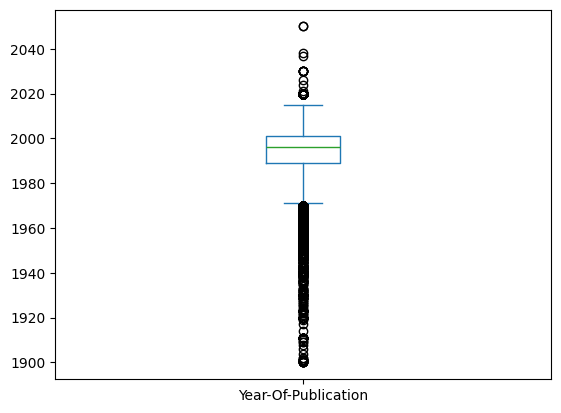

In [91]:
import matplotlib.pyplot as plt
books["Year-Of-Publication"].plot(kind="box")
plt.show()

###  Detect outliers per publisher

In [92]:
group_outliers = books.groupby("Publisher")["Year-Of-Publication"].apply(
    lambda x: x[(x < x.quantile(0.25)-1.5*(x.quantile(0.75)-x.quantile(0.25))) |
                (x > x.quantile(0.75)+1.5*(x.quantile(0.75)-x.quantile(0.25)))]
)
print(group_outliers.head())

Publisher    
Other      6     2020.0
           11    2020.0
           23    2020.0
           28    2020.0
           35    2020.0
Name: Year-Of-Publication, dtype: float64


### Replace outliers with median

In [93]:
median_year = books["Year-Of-Publication"].median()
books["Year-Of-Publication"] = books["Year-Of-Publication"].apply(
    lambda x: median_year if (x < Q1 - 1.5*IQR or x > Q3 + 1.5*IQR) else x
)
print(books.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0     Other   
1  Richard Bruce Wright               2001.0     Other   
2          Carlo D'Este               1991.0     Other   
3      Gina Bari Kolata               2001.0     Other   
4       E. J. W. Barber               2001.0     Other   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

### Flag outliers with boolean column

In [94]:
books["Outlier"] = ((books["Year-Of-Publication"] < Q1 - 1.5*IQR) |
                    (books["Year-Of-Publication"] > Q3 + 1.5*IQR))
print(books[["Book-Title","Year-Of-Publication","Outlier"]].head())

                                          Book-Title  Year-Of-Publication  \
0                                Classical Mythology               2002.0   
1                                       Clara Callan               2001.0   
2                               Decision in Normandy               1991.0   
3  Flu: The Story of the Great Influenza Pandemic...               2001.0   
4                             The Mummies of Urumchi               2001.0   

   Outlier  
0    False  
1    False  
2    False  
3    False  
4    False  


### Use quantile thresholds

In [95]:
low = books["Year-Of-Publication"].quantile(0.01)
high = books["Year-Of-Publication"].quantile(0.99)
outliers_quantile = books[(books["Year-Of-Publication"] < low) |
                          (books["Year-Of-Publication"] > high)]
print(outliers_quantile.head())

            ISBN                 Book-Title           Book-Author  \
396   0020437501               Rosie'S Walk          Pat Hutchins   
699   0684717255                 I And Thou          Martin Buber   
726   225300670X  A l'Ouest rien de nouveau  Erich Maria Remarque   
730   2253007102          Les Fleurs Du Mal         C. Baudelaire   
1393  0394404289                The Prophet         Kahlil Gibran   

      Year-Of-Publication Publisher  \
396                1971.0     Other   
699                1971.0     Other   
726                1973.0     Other   
730                1972.0     Other   
1393               1973.0     Other   

                                            Image-URL-S  \
396   http://images.amazon.com/images/P/0020437501.0...   
699   http://images.amazon.com/images/P/0684717255.0...   
726   http://images.amazon.com/images/P/225300670X.0...   
730   http://images.amazon.com/images/P/2253007102.0...   
1393  http://images.amazon.com/images/P/0394404289.0...

### Use quantile thresholds

In [96]:
low = books["Year-Of-Publication"].quantile(0.01)
high = books["Year-Of-Publication"].quantile(0.99)
outliers_quantile = books[(books["Year-Of-Publication"] < low) |
                          (books["Year-Of-Publication"] > high)]
print(outliers_quantile.head())

            ISBN                 Book-Title           Book-Author  \
396   0020437501               Rosie'S Walk          Pat Hutchins   
699   0684717255                 I And Thou          Martin Buber   
726   225300670X  A l'Ouest rien de nouveau  Erich Maria Remarque   
730   2253007102          Les Fleurs Du Mal         C. Baudelaire   
1393  0394404289                The Prophet         Kahlil Gibran   

      Year-Of-Publication Publisher  \
396                1971.0     Other   
699                1971.0     Other   
726                1973.0     Other   
730                1972.0     Other   
1393               1973.0     Other   

                                            Image-URL-S  \
396   http://images.amazon.com/images/P/0020437501.0...   
699   http://images.amazon.com/images/P/0684717255.0...   
726   http://images.amazon.com/images/P/225300670X.0...   
730   http://images.amazon.com/images/P/2253007102.0...   
1393  http://images.amazon.com/images/P/0394404289.0...

### Detect outliers with standard deviation

In [97]:
mean = books["Year-Of-Publication"].mean()
std = books["Year-Of-Publication"].std()
outliers_std = books[(books["Year-Of-Publication"] < mean - 3*std) |
                     (books["Year-Of-Publication"] > mean + 3*std)]
print(outliers_std.head())

            ISBN                            Book-Title       Book-Author  \
396   0020437501                          Rosie'S Walk      Pat Hutchins   
699   0684717255                            I And Thou      Martin Buber   
730   2253007102                     Les Fleurs Du Mal     C. Baudelaire   
1472  0486203077  Tales of Terror and the Supernatural    Wilkie Collins   
1613  2070360075              Le Vieil Homme et la Mer  Ernest Hemingway   

      Year-Of-Publication Publisher  \
396                1971.0     Other   
699                1971.0     Other   
730                1972.0     Other   
1472               1972.0     Other   
1613               1972.0     Other   

                                            Image-URL-S  \
396   http://images.amazon.com/images/P/0020437501.0...   
699   http://images.amazon.com/images/P/0684717255.0...   
730   http://images.amazon.com/images/P/2253007102.0...   
1472  http://images.amazon.com/images/P/0486203077.0...   
1613  http://

### Remove outliers with standard deviation

In [99]:
filtered_std = books[(books["Year-Of-Publication"] >= mean - 3*std) &
                     (books["Year-Of-Publication"] <= mean + 3*std)]
print(filtered_std.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication Publisher  \
0    Mark P. O. Morford               2002.0     Other   
1  Richard Bruce Wright               2001.0     Other   
2          Carlo D'Este               1991.0     Other   
3      Gina Bari Kolata               2001.0     Other   
4       E. J. W. Barber               2001.0     Other   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0...   
3  http://images.a

###  Summarize outlier detection


In [100]:
print("IQR outliers:", outliers.shape[0])
print("Z-score outliers:", outliers_z.shape[0])
print("Quantile outliers:", outliers_quantile.shape[0])
print("Std Dev outliers:", outliers_std.shape[0])

IQR outliers: 20350
Z-score outliers: 1595
Quantile outliers: 2281
Std Dev outliers: 1308


## 1.6 Perform Vectorized String Functions in Pandas. 

### Convert to lowercase

In [101]:
books["Book-Title"] = books["Book-Title"].str.lower()
print(books["Book-Title"].head())

0                                  classical mythology
1                                         clara callan
2                                 decision in normandy
3    flu: the story of the great influenza pandemic...
4                               the mummies of urumchi
Name: Book-Title, dtype: str


### Convert to uppercase

In [102]:
books["Book-Title"] = books["Book-Title"].str.upper()
print(books["Book-Title"].head())

0                                  CLASSICAL MYTHOLOGY
1                                         CLARA CALLAN
2                                 DECISION IN NORMANDY
3    FLU: THE STORY OF THE GREAT INFLUENZA PANDEMIC...
4                               THE MUMMIES OF URUMCHI
Name: Book-Title, dtype: str


### Capitalize first letter


In [103]:
books["Book-Title"] = books["Book-Title"].str.capitalize()
print(books["Book-Title"].head())

0                                  Classical mythology
1                                         Clara callan
2                                 Decision in normandy
3    Flu: the story of the great influenza pandemic...
4                               The mummies of urumchi
Name: Book-Title, dtype: str


###  Title case

In [104]:
books["Book-Title"] = books["Book-Title"].str.title()
print(books["Book-Title"].head())

0                                  Classical Mythology
1                                         Clara Callan
2                                 Decision In Normandy
3    Flu: The Story Of The Great Influenza Pandemic...
4                               The Mummies Of Urumchi
Name: Book-Title, dtype: str


### Strip whitespace

In [105]:
books["Book-Title"] = books["Book-Title"].str.strip()
print(books["Book-Title"].head())

0                                  Classical Mythology
1                                         Clara Callan
2                                 Decision In Normandy
3    Flu: The Story Of The Great Influenza Pandemic...
4                               The Mummies Of Urumchi
Name: Book-Title, dtype: str


### Extract substring 

In [106]:
books["Short-Title"] = books["Book-Title"].str[:10]
print(books[["Book-Title","Short-Title"]].head())

                                          Book-Title Short-Title
0                                Classical Mythology  Classical 
1                                       Clara Callan  Clara Call
2                               Decision In Normandy  Decision I
3  Flu: The Story Of The Great Influenza Pandemic...  Flu: The S
4                             The Mummies Of Urumchi  The Mummie


### Replace substrings

In [107]:
books["Publisher"] = books["Publisher"].str.replace("Press","Pub", regex=False)
print(books["Publisher"].head())

0    Other
1    Other
2    Other
3    Other
4    Other
Name: Publisher, dtype: str


###  Check if string contains keyword

In [108]:
mask = books["Book-Title"].str.contains("Python", case=False, na=False)
print(books[mask].head())

             ISBN                                         Book-Title  \
30133  0679726489  The Complete Monty Python'S Flying Circus : Al...   
30134  0679726470  The Complete Monty Python'S Flying Circus : Al...   
45392  0312033095                 The First 20 Years Of Monty Python   
45500  0316700150                                     Life Of Python   
45502  1575000369                          Monty Python Encyclopedia   

              Book-Author  Year-Of-Publication Publisher  \
30133      Graham Chapman               1989.0     Other   
30134      Graham Chapman               1989.0     Other   
45392  Kim Howard Johnson               1989.0     Other   
45500        George Perry               1984.0     Other   
45502         Robert Ross               2001.0     Other   

                                             Image-URL-S  \
30133  http://images.amazon.com/images/P/0679726489.0...   
30134  http://images.amazon.com/images/P/0679726470.0...   
45392  http://images.amazo

###  Split strings


In [110]:
 
books["Author-First"] = books["Book-Author"].str.split().str[0]
print(books[["Book-Author","Author-First"]].head())






            Book-Author Author-First
0    Mark P. O. Morford         Mark
1  Richard Bruce Wright      Richard
2          Carlo D'Este        Carlo
3      Gina Bari Kolata         Gina
4       E. J. W. Barber           E.


### Length of strings

In [111]:
books["Title-Length"] = books["Book-Title"].str.len()
print(books[["Book-Title","Title-Length"]].head())

                                          Book-Title  Title-Length
0                                Classical Mythology            19
1                                       Clara Callan            12
2                               Decision In Normandy            20
3  Flu: The Story Of The Great Influenza Pandemic...            98
4                             The Mummies Of Urumchi            22


### Detect missing strings

In [114]:
missing_titles = books["Book-Title"].str.len().isna()
print(books[missing_titles].head())

Empty DataFrame
Columns: [ISBN, Book-Title, Book-Author, Year-Of-Publication, Publisher, Image-URL-S, Image-URL-M, Image-URL-L, Year-Bin, Outlier, Short-Title, Author-First, Title-Length, Author-Info]
Index: []


###  Concatenate strings

In [113]:
books["Author-Info"] = books["Book-Author"].str.cat(books["Publisher"], sep=" - ")
print(books[["Book-Author","Publisher","Author-Info"]].head())

            Book-Author Publisher                   Author-Info
0    Mark P. O. Morford     Other    Mark P. O. Morford - Other
1  Richard Bruce Wright     Other  Richard Bruce Wright - Other
2          Carlo D'Este     Other          Carlo D'Este - Other
3      Gina Bari Kolata     Other      Gina Bari Kolata - Other
4       E. J. W. Barber     Other       E. J. W. Barber - Other


###  Extract digits





In [115]:
books["Digits"] = books["ISBN"].str.extract("(\d+)")
print(books[["ISBN","Digits"]].head())

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ramya\AppData\Local\Temp\ipykernel_12460\3869133611.py:1: SyntaxWarning: invalid escape sequence '\d'
  books["Digits"] = books["ISBN"].str.extract("(\d+)")


         ISBN      Digits
0  0195153448  0195153448
1  0002005018  0002005018
2  0060973129  0060973129
3  0374157065  0374157065
4  0393045218  0393045218


### Find position of substring

In [116]:
books["Python-Pos"] = books["Book-Title"].str.find("Python")
print(books[["Book-Title","Python-Pos"]].head())

                                          Book-Title  Python-Pos
0                                Classical Mythology          -1
1                                       Clara Callan          -1
2                               Decision In Normandy          -1
3  Flu: The Story Of The Great Influenza Pandemic...          -1
4                             The Mummies Of Urumchi          -1


### Count occurrences of substring

In [117]:
books["Count-Python"] = books["Book-Title"].str.count("Python")
print(books[["Book-Title","Count-Python"]].head())

                                          Book-Title  Count-Python
0                                Classical Mythology             0
1                                       Clara Callan             0
2                               Decision In Normandy             0
3  Flu: The Story Of The Great Influenza Pandemic...             0
4                             The Mummies Of Urumchi             0
